# 📘 Lesson 05 — Advanced Uses of SHAP Values
- Explainability Machine Learning — Study Companion (Moacir)
- Hybrid Learning Notebook — Study + Reference + Hands-on

Versão compatível com SHAP moderno (>= 0.51), usando a API nova:
- `shap.Explainer`
- `shap.plots.beeswarm`
- `shap.plots.scatter`

# 1) Objetivos da Lesson

- Revisar a ideia de SHAP values como decomposição de uma previsão.
- Gerar **gráficos de resumo (beeswarm)** para entender importância global + distribuição de efeitos.
- Gerar **gráficos de dependência (scatter)** para investigar interações entre features.
- Comparar esses gráficos com Permutation Importance e PDPs.
- Interpretar padrões de cor, dispersão e magnitude nos gráficos de SHAP.

# 2) Glossário Técnico

- **SHAP Value** — contribuição de uma feature para deslocar a previsão em relação a um baseline.
- **Baseline (expected value)** — previsão média do modelo antes de considerar as features do exemplo.
- **Beeswarm Plot (SHAP Summary)** — gráfico que mostra, para muitas instâncias, a distribuição dos SHAP values por feature.
- **SHAP Dependence Plot (scatter)** — gráfico que mostra, para uma feature, como seu valor se relaciona com seu SHAP value.
- **Interação** — quando o efeito de uma feature depende do valor de outra.
- **Impacto na previsão** — quanto uma feature aumenta ou diminui a probabilidade / valor previsto.

# 3) Mini‑Referência (API Style)

- `pandas.read_csv(path)`
- `train_test_split(X, y, random_state=...)`
- `RandomForestClassifier(n_estimators=..., random_state=...)`
- `RandomForestClassifier.fit(X, y)`
- `shap.Explainer(model, X_background)`
- `explainer(X)` → retorna objeto com `.values`, `.base_values`, `.data`
- `shap.plots.beeswarm(shap_values, max_display=...)`
- `shap.plots.scatter(shap_values[:, feature_idx], color=shap_values[:, other_idx])`

# 4) Introdução Conceitual (Book‑Style)

Até aqui, você já viu:
- **Permutation Importance** → mede *quanto* cada feature importa em média.
- **PDPs** → mostram *como* a previsão média muda ao variar uma feature.
- **SHAP Values (locais)** → explicam *por que* uma previsão específica foi feita.

Nesta lesson, o foco é:

> **Usar muitos SHAP values ao mesmo tempo para entender o modelo como um todo.**

Em vez de olhar apenas para um paciente por vez, vamos:
- olhar para centenas de pacientes simultaneamente;
- ver como cada feature afeta as previsões em diferentes situações;
- identificar interações e efeitos não lineares.

Com a API moderna do SHAP, fazemos isso com:
- `shap.Explainer` → cálculo dos SHAP values;
- `shap.plots.beeswarm` → resumo global;
- `shap.plots.scatter` → dependência + interação.

# 5) Implementação passo a passo

Vamos usar o mesmo dataset sintético de readmissões médicas
(`medical_readmissions.csv`), mantendo consistência com as lessons anteriores.

## 5.1. Configuração de caminhos + importação de bibliotecas

In [1]:
import sys
from pathlib import Path

# Caminho absoluto do notebook
notebook_path = Path().resolve()

# Sobe diretórios até encontrar config.py (mesmo padrão das lessons anteriores)
for parent in notebook_path.parents:
    if (parent / "config.py").exists():
        sys.path.append(str(parent))
        break

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import shap
import matplotlib.pyplot as plt

from config import get_data_path

DATA_PATH = get_data_path()
print("DATA_PATH:", DATA_PATH)

DATA_PATH: ../data/raw/


## 5.2. Carregar o dataset sintético e selecionar features

Inspirado na lesson do Kaggle:
- target: `readmitted`
- subconjunto de features clínicas e administrativas.

In [3]:
df = pd.read_csv(DATA_PATH + "medical_readmissions.csv")
df.head()

,age,gender,race,admission_type,time_in_hospital,time_in_hospital_scaled,num_procedures,num_medications,lab_tests,bmi_estimate,socks_owned,favorite_color,diabetes,hypertension,readmitted
0,62.450712,Female,Hispanic,Emergency,3,3.0,0,3,45.280360,21.610513,18,Blue,No,Yes,0
1,52.926035,Female,White,Emergency,4,4.0,5,3,32.315645,16.338189,6,Red,Yes,No,0
2,64.715328,Female,Other,Emergency,4,4.0,1,4,40.490947,23.851009,5,Blue,Yes,No,0
3,77.845448,Male,Asian,Urgent,6,6.0,3,4,26.482925,28.906129,4,Green,No,No,0
4,51.487699,Male,Black,Emergency,12,12.0,2,9,46.858905,11.503526,3,Green,Yes,No,0


In [4]:
target_col = "readmitted"

if target_col not in df.columns:
    raise ValueError(f"Coluna alvo '{target_col}' não encontrada no dataset.")

y = df[target_col]

candidate_features = [
    "number_inpatient",
    "num_medications",
    "number_diagnoses",
    "num_lab_procedures",
    "num_procedures",
    "time_in_hospital",
    "number_outpatient",
    "number_emergency",
    "gender_Female",
    "payer_code_?",
    "medical_specialty_?",
    "diag_1_428",
    "diag_1_414",
    "diabetesMed_Yes",
    "A1Cresult_None",
]

base_features = [c for c in candidate_features if c in df.columns]

if len(base_features) == 0:
    raise ValueError("Nenhuma das base_features esperadas foi encontrada no dataset.")

print("Features usadas nos gráficos SHAP:")
print(base_features)

X = df[base_features].astype(float)

Features usadas nos gráficos SHAP:
['num_medications', 'num_procedures', 'time_in_hospital']


## 5.3. Dividir em treino e validação + treinar modelo base

In [5]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=1
)

model = RandomForestClassifier(
    n_estimators=30,
    random_state=1
)
model.fit(X_train, y_train)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 5.4. Criar o Explainer e calcular SHAP values

Com a API moderna:
- usamos `shap.Explainer(model, X_background)`
- depois chamamos `explainer(X_valid_subset)`.

In [6]:
# Para acelerar, usamos um subconjunto da validação
small_X_valid = X_valid.iloc[:150].copy()

# Usamos uma pequena amostra de treino como "background"
background = X_train.sample(100, random_state=1)

explainer = shap.Explainer(model, background)
shap_values = explainer(small_X_valid)

# `shap_values` é um objeto do tipo Explanation
type(shap_values), shap_values.values.shape

(shap._explanation.Explanation, (150, 3, 2))

## 5.5. SHAP Summary (Beeswarm) — visão global rica

`shap.plots.beeswarm` é a versão moderna do summary plot:
- ordena as features por importância;
- mostra distribuição dos SHAP values;
- usa cor para indicar valor da feature.

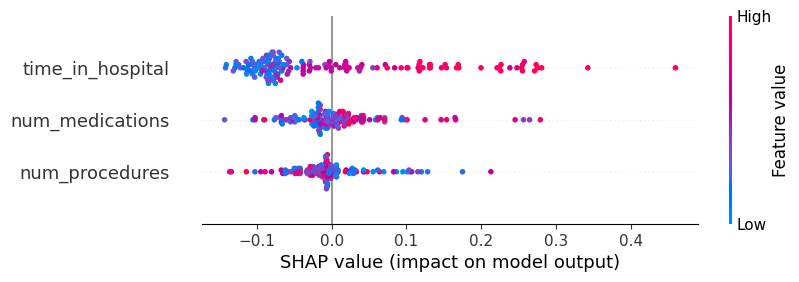

In [8]:
shap_values_class1 = shap_values[..., 1]
shap.plots.beeswarm(shap_values_class1, max_display=15)

**Perguntas para reflexão:**

- Quais features aparecem no topo (maior impacto global)?
- Para `number_inpatient`, valores altos (rosa) tendem a aumentar ou diminuir o risco?
- Para `num_lab_procedures`, os pontos azuis e rosas estão bem separados ou misturados?
- Alguma feature parece quase ignorada pelo modelo?

## 5.6. SHAP Dependence (Scatter) — efeito + interação

Com a API moderna, usamos:
- `shap.plots.scatter(shap_values[:, feature_idx], color=shap_values[:, other_idx])`

Feature principal: num_medications
Feature de interação: num_procedures


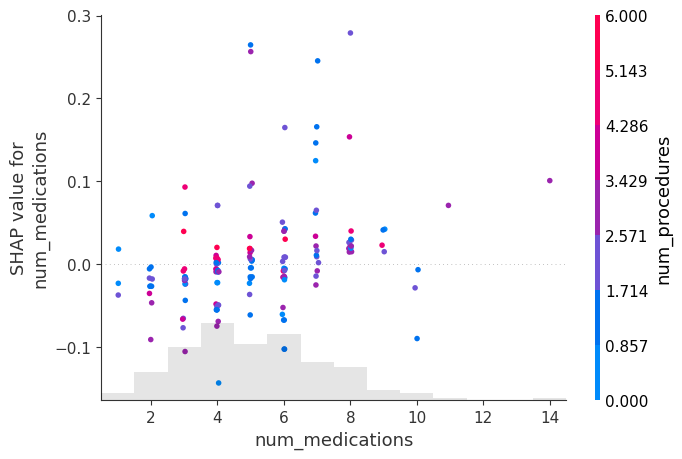

In [10]:
# Escolher automaticamente a primeira feature numérica
feature_name = base_features[0]

# Escolher automaticamente outra feature para interação (se existir)
interaction_name = base_features[1] if len(base_features) > 1 else None

print("Feature principal:", feature_name)
print("Feature de interação:", interaction_name)

feature_idx = base_features.index(feature_name)

if interaction_name is not None:
    interaction_idx = base_features.index(interaction_name)
    shap.plots.scatter(
        shap_values_class1[:, feature_idx],
        color=shap_values_class1[:, interaction_idx],
        show=True
    )
else:
    shap.plots.scatter(
        shap_values_class1[:, feature_idx],
        show=True
    )


**Interpretação sugerida:**

- Eixo X: valor da feature (`number_inpatient`).
- Eixo Y: SHAP value (impacto na previsão).
- Cor: valor de `num_medications` (se usado).

Pergunte-se:
- O impacto de `number_inpatient` cresce de forma aproximadamente monotônica?
- Há muita dispersão vertical (sinal de interação com outras features)?
- A cor sugere que o efeito muda quando `num_medications` é alto ou baixo?

## 5.7. Comparando com Permutation Importance e PDPs

- **Permutation Importance**:
  - fornece um número médio de importância por feature;
  - não mostra distribuição de efeitos nem interações.

- **PDPs**:
  - mostram a curva média de efeito de uma feature;
  - escondem variação individual.

- **SHAP (beeswarm + scatter)**:
  - mostram importância global **e** distribuição de efeitos;
  - revelam interações via cor e dispersão;
  - conectam visão global e local em um único framework.

# 6) Observações pedagógicas do Copilot

- A API moderna do SHAP (`shap.Explainer`) é mais robusta e compatível com versões recentes de NumPy.
- Conceitualmente, nada muda em relação à lesson do Kaggle:
  - ainda estamos decompondo previsões em contribuições por feature;
  - ainda estamos agregando essas contribuições para entender o modelo.
- Diferenças principais:
  - em vez de `TreeExplainer` + `shap_values[1]`, usamos `Explainer` + `Explanation`;
  - em vez de `summary_plot`, usamos `plots.beeswarm`;
  - em vez de `dependence_plot`, usamos `plots.scatter`.
- Boas práticas:
  - usar subconjuntos de dados para não ficar lento;
  - sempre interpretar gráficos com alguém do domínio;
  - tratar insights como hipóteses, não causalidade.

# 7) Conclusão

Nesta lesson, você:

- revisitou a ideia de SHAP values como decomposição de previsões;
- gerou **beeswarm plots** (summary) para entender:
  - importância global;
  - distribuição de efeitos;
  - sinais de interação;
- gerou **scatter plots de dependência** para:
  - ver a relação entre valor da feature e impacto na previsão;
  - investigar interações via cor;
- comparou essas visualizações com Permutation Importance e PDPs.

Mensagem central:

> **Agregando SHAP values, você ganha uma visão global rica, sem perder a granularidade local.**

Esta versão do notebook é compatível com SHAP moderno e mantém o espírito da Lesson 05 do Kaggle,
permitindo que você aplique os mesmos conceitos em qualquer ambiente Python atual.